In [1]:
import pandas as pd
import json
import seaborn.objects as so
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
plt.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 16,      # title font size
    'axes.labelsize': 14,      # x/y label font size
    'xtick.labelsize': 14,     # x-tick labels
    'ytick.labelsize': 14,     # y-tick labels
    'legend.fontsize': 14,     # legend text
    'figure.titlesize': 16     # overall figure title
    
})

In [3]:
sns.set_theme(style="whitegrid")

In [4]:
def read_jsonl_to_dataframe(jsonl_path):
    # Reads a .jsonl file and returns a pandas DataFrame.
    with open(jsonl_path, "r", encoding="utf-8") as f:
        records = [json.loads(line) for line in f]
    return pd.DataFrame(records)

def get_majority_labels(dataframes):
    combined = pd.concat(dataframes, ignore_index=True)
    majority_labels = (
        combined.groupby(['layer_index', 'prompt'])['label']
        .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0])
        .reset_index()
    )
    return majority_labels



In [5]:
label_name_mapping = {
    'user': 'User persona',
    'llm': 'LLM persona',
    'not coherent': 'Not coherent'
}

In [33]:
# model_id = "llama31_8B"
model_id = "llama31_8B_instruct"
# model_id = "qwen25_7B_instruct"

# Layer steering

## Negative and positive

In [31]:
model_neg = [read_jsonl_to_dataframe(f"llm_as_a_judge_results/layer_steering/{model_id}/neg/run_{i+1}.jsonl") for i in range(5)]
model_pos = [read_jsonl_to_dataframe(f"llm_as_a_judge_results/layer_steering/{model_id}/pos/run_{i+1}.jsonl") for i in range(5)]

# Apply to both datasets
model_neg_majority = get_majority_labels([model_neg[i] for i in range(5)])
model_pos_majority = get_majority_labels([model_pos[i] for i in range(5)])


In [25]:
all_labels = pd.concat([model_neg_majority['label'], model_pos_majority['label']]).unique()
colorblind_palette = sns.color_palette("colorblind", n_colors=len(all_labels))
color_mapping = dict(zip(all_labels, colorblind_palette))

# Update color_mapping to use new labels
color_mapping_display = {
    'User persona': color_mapping['user'],
    'LLM persona': color_mapping['llm'],
    'Not coherent': color_mapping['not coherent']
}

# Define the legend order
legend_order = ['User persona', 'LLM persona', 'Not coherent']

None


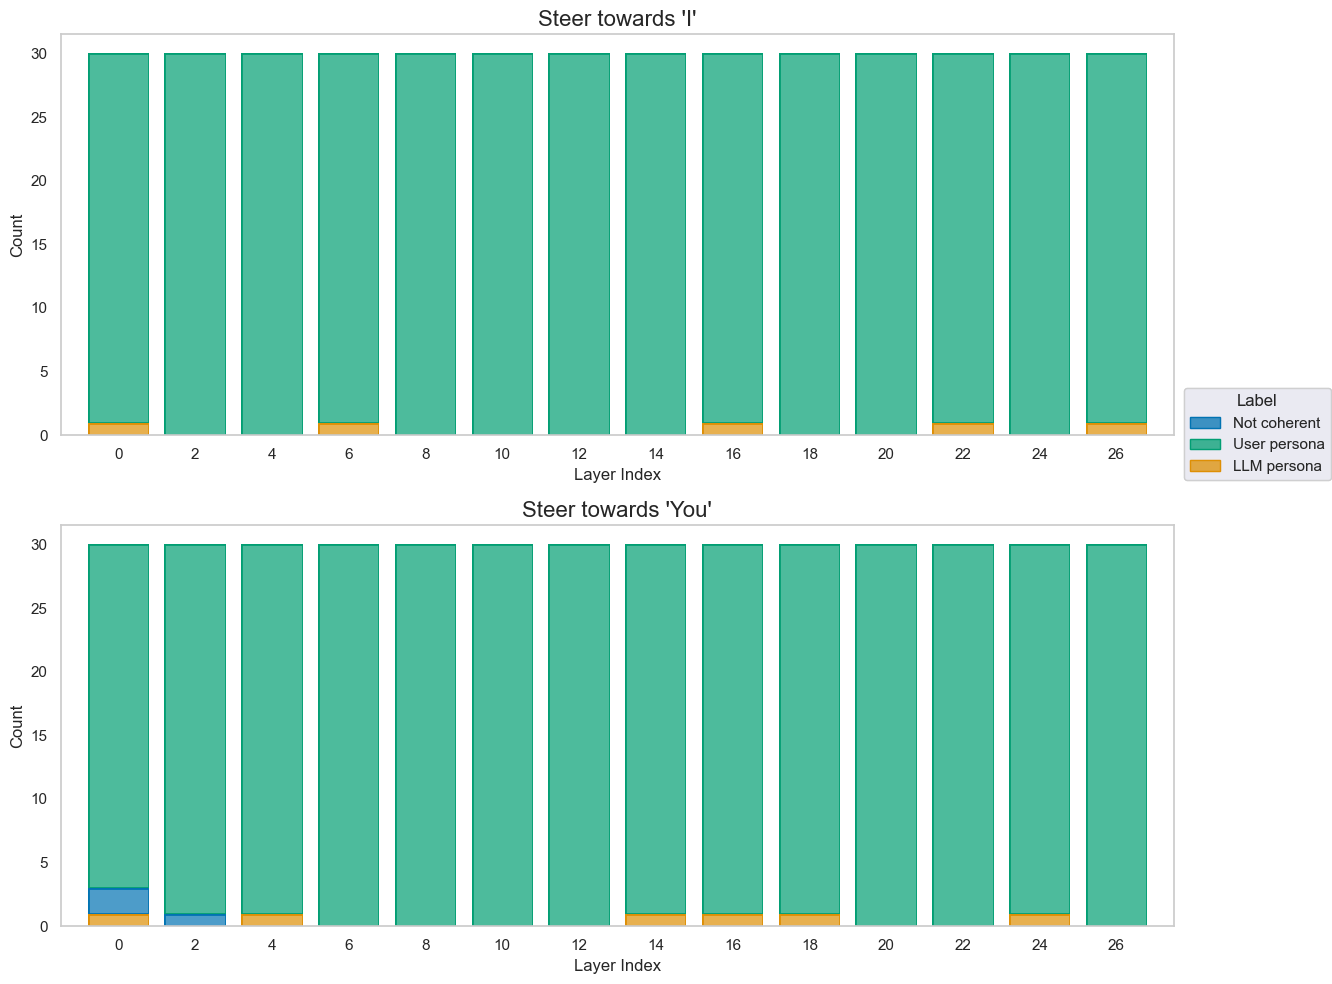

In [32]:
# plt.rcParams.update({'font.size': 18})
# Create label mapping

legend_order = ['Not coherent', 'User persona', 'LLM persona']

# Prepare negative data
model_neg_majority['layer_index'] = model_neg_majority['layer_index'].astype(int)
# Map labels to display names
model_neg_majority['label_display'] = model_neg_majority['label'].map(label_name_mapping)
model_neg_counts = model_neg_majority.groupby(['layer_index', 'label_display']).size().reset_index(name='count')
model_neg_counts = model_neg_counts.sort_values('layer_index', ascending=True)
min_layer_neg = model_neg_counts['layer_index'].min()
max_layer_neg = model_neg_counts['layer_index'].max()

# Prepare positive data
model_pos_majority['layer_index'] = model_pos_majority['layer_index'].astype(int)
# Map labels to display names
model_pos_majority['label_display'] = model_pos_majority['label'].map(label_name_mapping)
model_pos_counts = model_pos_majority.groupby(['layer_index', 'label_display']).size().reset_index(name='count')
model_pos_counts = model_pos_counts.sort_values('layer_index', ascending=True)
min_layer_pos = model_pos_counts['layer_index'].min()
max_layer_pos = model_pos_counts['layer_index'].max()


# Create figure with two subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))


# Plot 2 - Positive (bottom)
p1 = (
    so.Plot(model_pos_counts, x="layer_index", y="count", color="label_display")
    .add(so.Bar(), so.Stack())
    .scale(
        color=so.Nominal(color_mapping_display, order=legend_order),
        x=so.Continuous().tick(every=2)
    )
    .limit(x=(min_layer_pos - 1.5, max_layer_pos + 1.5))
    .label(
        title="Steer towards 'I'",
        x="Layer Index",
        y="Count",
        color="Label"
    )
    .on(ax1)
    .plot()
)


# Plot 1 - Negative (top)
p2 = (
    so.Plot(model_neg_counts, x="layer_index", y="count", color="label_display")
    .add(so.Bar(), so.Stack())
    .scale(
        color=so.Nominal(color_mapping_display, order=legend_order),
        x=so.Continuous().tick(every=2)
    )
    .limit(x=(min_layer_neg - 1.5, max_layer_neg + 1.5))
    .label(
        title="Steer towards 'You'",
        x="Layer Index",
        y="Count",
        color="Label"
    )
    .on(ax2)
    .plot()
)

ax1.set_title("Steer towards 'I'", fontsize=16)
ax2.set_title("Steer towards 'You'", fontsize=16)

ax1.grid(False)
ax2.grid(False)

# Reposition legends for both plots
# ax1.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))
# # ax1.legend_.remove()
# ax2.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))

print(ax1.get_legend())

plt.tight_layout()
plt.savefig(f"./plots/{model_id}_steer_layer_final.pdf", dpi=300, bbox_inches='tight')

## Neutral

In [ ]:
model_neutral = [read_jsonl_to_dataframe(f"llm_as_a_judge_results/llama/neutral/run_{i+1}.jsonl") for i in range(5)]
model_neutral_majority = get_majority_labels([model_neutral[i] for i in range(5)])

In [ ]:
model_neg_majority_12 = model_neg_majority[model_neg_majority['layer_index'] == '12'].reset_index(drop=True)
model_pos_majority_12 = model_pos_majority[model_pos_majority['layer_index'] == '12'].reset_index(drop=True)

In [ ]:
model_neg_majority_12['layer_index'] = "Negative"
model_pos_majority_12['layer_index'] = "Positive"
model_neutral_majority['layer_index'] = "Neutral"

In [ ]:
llama_combined = pd.concat([model_neg_majority_12, model_neutral_majority, model_pos_majority_12]).reset_index(drop=True)
llama_combined.shape

(90, 3)

In [49]:
llama_combined.head()

,layer_index,prompt,label
0,Negative,Am anxious,llm
1,Negative,Am excited,llm
2,Negative,Am sad,llm
3,Negative,Explain the meaning of life,llm
4,Negative,Feel happy,llm


In [50]:
# Apply the mapping
llama_combined['label_display'] = llama_combined['label'].map(label_name_mapping)

# Now do the groupby
llama_combined_counts = llama_combined.groupby(['layer_index', 'label_display']).size().reset_index(name='count')

print(f"\nGrouped data shape: {llama_combined_counts.shape}")
print("\nGrouped data:")
print(llama_combined_counts)


Grouped data shape: (4, 3)

Grouped data:
  layer_index label_display  count
0    Negative   LLM persona     30
1     Neutral   LLM persona      4
2     Neutral  User persona     26
3    Positive  User persona     30


In [ ]:
# Pivot the data for stacked bar chart
pivot_data = llama_combined_counts.pivot(index='layer_index', columns='label_display', values='count').fillna(0)

# Reorder if needed
pivot_data = pivot_data.reindex(['Negative', 'emotions', 'Positive'])

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Create stacked bar chart
pivot_data.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[color_mapping_display.get(col) for col in pivot_data.columns],
    width=0.6
)

ax.set_title("Neutral Steering", fontsize=16)
ax.set_xlabel("Layer Index", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.legend(title="Label", loc='upper right', frameon=True)
ax.grid(False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("steer_layer_neutral.pdf", dpi=300, bbox_inches='tight')
plt.show()

/scratch/ipykernel_701414/259840254.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))


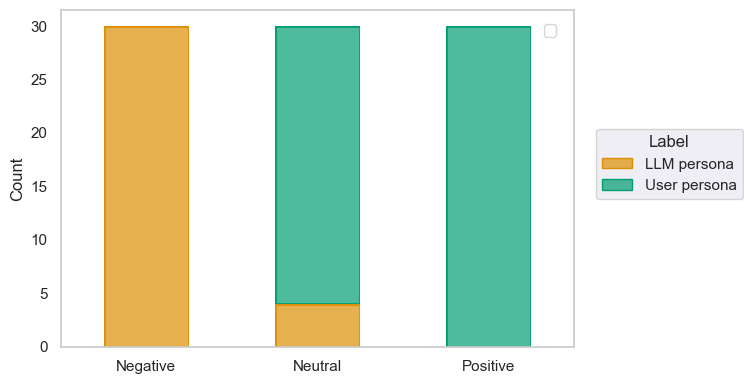

In [61]:

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot with categorical x-axis, set bar width using .add(so.Bar(width=0.8), ...)
p = (
    so.Plot(llama_combined_counts, x="layer_index", y="count", color="label_display")
    .add(so.Bar(width=0.5), so.Stack())  # Set the bar width here
    .scale(color=color_mapping_display)
    .label(
        # title="Neutral Steering",
        x="",
        y="Count",
        color="Label"
    )
    .on(ax)
    .plot()
)

# ax.set_title("", fontsize=16)
ax.grid(False)
ax.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.savefig("steer_layer_neutral.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Sensitivity

## Negative and positive

In [34]:
model_neg = [read_jsonl_to_dataframe(f"llm_as_a_judge_results/sensitivity/{model_id}/neg/run_{i+1}.jsonl") for i in range(5)]
model_pos = [read_jsonl_to_dataframe(f"llm_as_a_judge_results/sensitivity/{model_id}/pos/run_{i+1}.jsonl") for i in range(5)]

# Apply to both datasets
model_neg_majority = get_majority_labels([model_neg[i] for i in range(5)])
model_pos_majority = get_majority_labels([model_pos[i] for i in range(5)])


In [35]:
all_labels = pd.concat([model_neg_majority['label'], model_pos_majority['label']]).unique()
colorblind_palette = sns.color_palette("colorblind", n_colors=len(all_labels))
color_mapping = dict(zip(all_labels, colorblind_palette))

# Update color_mapping to use new labels
color_mapping_display = {
    'User persona': color_mapping['user'],
    'LLM persona': color_mapping['llm'],
    'Not coherent': color_mapping['not coherent']
}

# Define the legend order
legend_order = ['User persona', 'LLM persona', 'Not coherent']

None


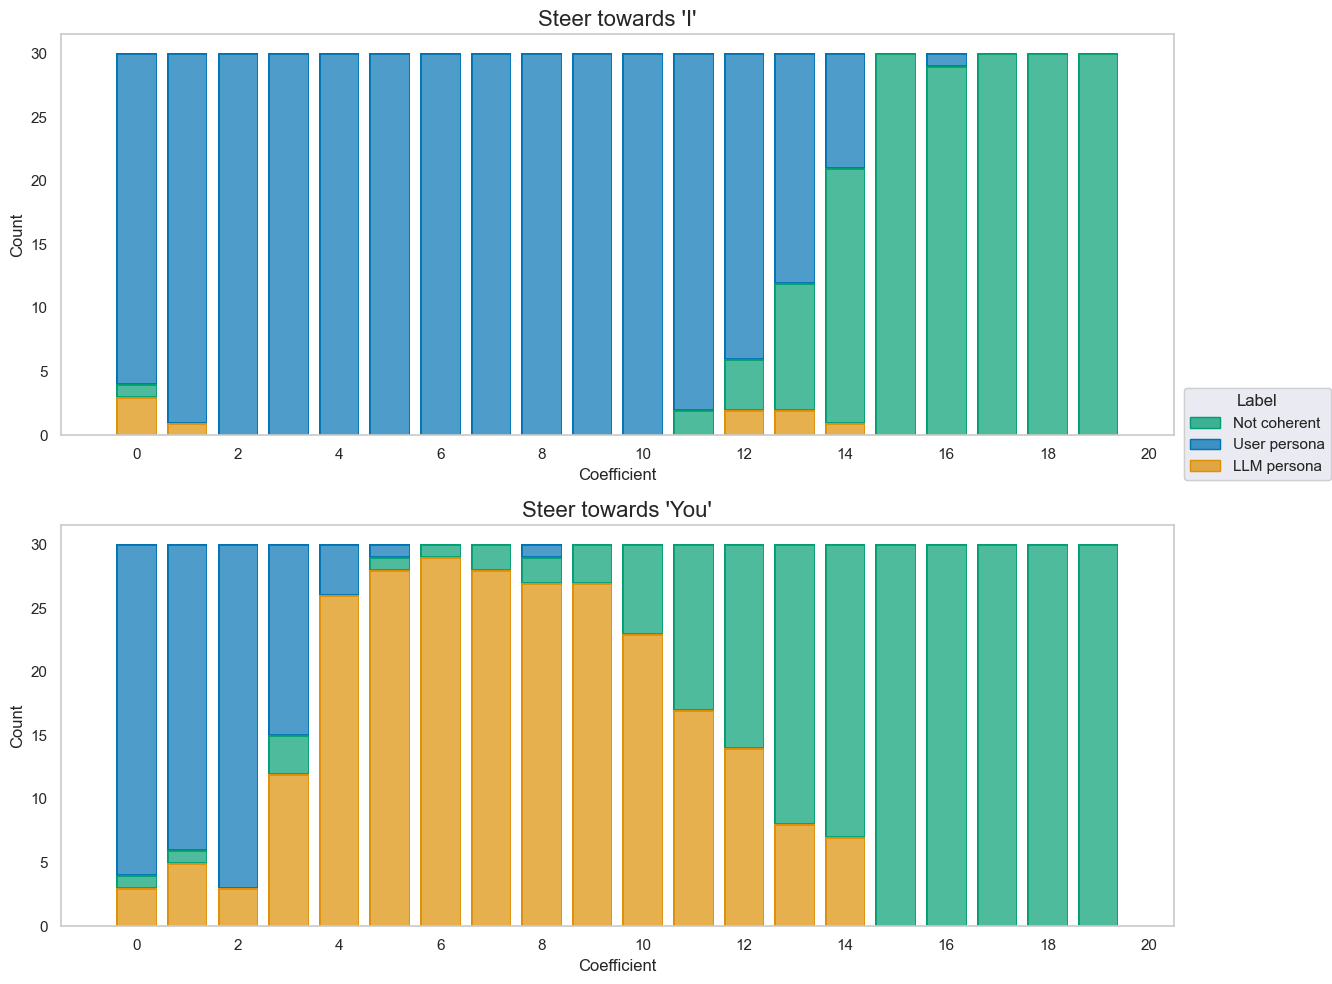

In [36]:
# plt.rcParams.update({'font.size': 18})
# Create label mapping

legend_order = ['Not coherent', 'User persona', 'LLM persona']

# Prepare negative data
model_neg_majority['layer_index'] = model_neg_majority['layer_index'].astype(int)
# Map labels to display names
model_neg_majority['label_display'] = model_neg_majority['label'].map(label_name_mapping)
model_neg_counts = model_neg_majority.groupby(['layer_index', 'label_display']).size().reset_index(name='count')
model_neg_counts = model_neg_counts.sort_values('layer_index', ascending=True)
min_layer_neg = model_neg_counts['layer_index'].min()
max_layer_neg = model_neg_counts['layer_index'].max()

# Prepare positive data
model_pos_majority['layer_index'] = model_pos_majority['layer_index'].astype(int)
# Map labels to display names
model_pos_majority['label_display'] = model_pos_majority['label'].map(label_name_mapping)
model_pos_counts = model_pos_majority.groupby(['layer_index', 'label_display']).size().reset_index(name='count')
model_pos_counts = model_pos_counts.sort_values('layer_index', ascending=True)
min_layer_pos = model_pos_counts['layer_index'].min()
max_layer_pos = model_pos_counts['layer_index'].max()



# Create figure with two subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))


# Plot 2 - Positive (bottom)
p1 = (
    so.Plot(model_pos_counts, x="layer_index", y="count", color="label_display")
    .add(so.Bar(), so.Stack())
    .scale(
        color=so.Nominal(color_mapping_display, order=legend_order),
        x=so.Continuous().tick(every=2)
    )
    .limit(x=(min_layer_pos - 1.5, max_layer_pos + 1.5))
    .label(
        title="Steer towards 'I'",
        x="Coefficient",
        y="Count",
        color="Label"
    )
    .on(ax1)
    .plot()
)


# Plot 1 - Negative (top)
p2 = (
    so.Plot(model_neg_counts, x="layer_index", y="count", color="label_display")
    .add(so.Bar(), so.Stack())
    .scale(
        color=so.Nominal(color_mapping_display, order=legend_order),
        x=so.Continuous().tick(every=2)
    )
    .limit(x=(min_layer_neg - 1.5, max_layer_neg + 1.5))
    .label(
        title="Steer towards 'You'",
        x="Coefficient",
        y="Count",
        color="Label"
    )
    .on(ax2)
    .plot()
)

ax1.set_title("Steer towards 'I'", fontsize=16)
ax2.set_title("Steer towards 'You'", fontsize=16)

ax1.grid(False)
ax2.grid(False)

# Reposition legends for both plots
# ax1.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))
# # ax1.legend_.remove()
# ax2.legend(loc='upper right', frameon=True, bbox_to_anchor=(0.98, 0.98))

print(ax1.get_legend())

plt.tight_layout()
# plt.show()
plt.savefig(f"./plots/{model_id}_sensitivity.pdf", dpi=300, bbox_inches='tight')